# Image classifier

The goal here is to train over a loop an image classifier with PyTorch

## Tensors

In [1]:
import torch
import numpy as np

In [2]:
shape = (2, 3)
zeros_tensor = torch.zeros(shape)

Transferer le tensor sur un GPU

In [5]:
if torch.accelerator.is_available():
    zeros_tensor = zeros_tensor.to(torch.accelerator.current_accelerator())

In [6]:
print(f"Device tensor is stored on: {zeros_tensor.device}")

Device tensor is stored on: cuda:0


## Dataset

### Loading a dataset

In [8]:
from torch.utils.data import Dataset
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt

In [9]:
training_data = datasets.CIFAR10(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.CIFAR10(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

100.0%


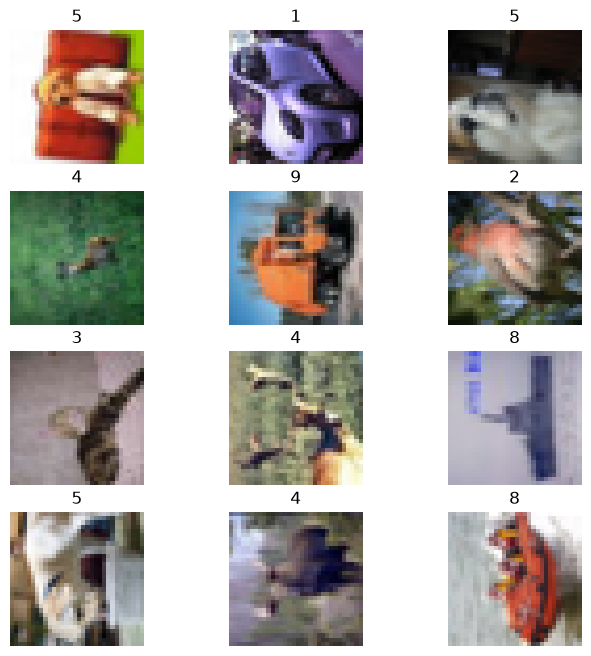

In [19]:
figure = plt.figure(figsize=(8, 8))
cols, rows = 3, 4
for i in range(1, cols * rows + 1):
    sample_idx = torch.randint(len(training_data), size=(1,)).item()
    img, label = training_data[sample_idx]
    figure.add_subplot(rows, cols, i)
    plt.title(label)
    plt.axis("off")
    plt.imshow(img.squeeze().T)
plt.show()

### Preparing data

Dataloader : easy iterable API

In [13]:
from torch.utils.data import DataLoader


train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)
test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)

Feature batch shape: torch.Size([64, 3, 32, 32])
Labels batch shape: torch.Size([64])


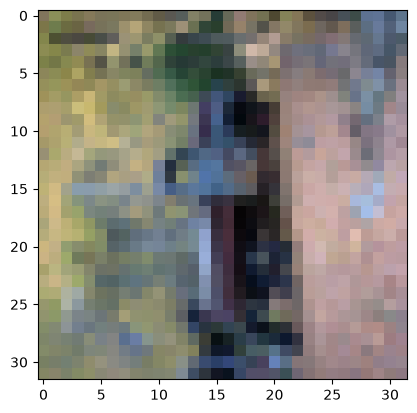

Label: 9


In [58]:
# Display image and label.
train_features, train_labels = next(iter(train_dataloader))
print(f"Feature batch shape: {train_features.size()}")
print(f"Labels batch shape: {train_labels.size()}")
img = train_features[0].squeeze()
label = train_labels[0]
plt.imshow(img.T)
plt.show()
print(f"Label: {label}")
